# Exploratory Data Analysis

### Data Loading, Initial Cleaning & Dataset Overview

- loaded data from month X
- renamed all columns to lowercase with underscores
- removed sparse and irrelevant metadata columns
- inspected data types, missing values, and urgency value counts

Result: Cleaned dataset with consistent column names and reduced noise for analysis

In [1]:
import pandas as pd

df1 = pd.read_excel('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/ioki/ml-service_now_tagging/data/untagged/1-7-Dec-merged.xlsx')
df2 = pd.read_excel('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/ioki/ml-service_now_tagging/data/untagged/08-Dec.xlsx')
df3 = pd.read_excel('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/ioki/ml-service_now_tagging/data/untagged/09-Dec.xlsx') 
df4 = pd.read_excel('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/ioki/ml-service_now_tagging/data/untagged/10-17-Dec-merged.xlsx')
df5 = pd.read_excel('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/ioki/ml-service_now_tagging/data/untagged/18-Dec.xlsx') 
df6 = pd.read_excel('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/ioki/ml-service_now_tagging/data/untagged/19-Dec-to-13-Jan-2026-merged.xlsx')
df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

#save the combined dataframe to a csv file
df.to_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/combined_data.csv', index=False)

In [2]:
# Rename all columns: lowercase and replace spaces with underscores
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

In [3]:
# delete all columns wiht less than 3200 entires
df = df.dropna(thresh=2300, axis=1)
df = df.drop(['updated', 'reporter','updated_by', 'status','reassignment_count','child_incidents','updated_by'], axis=1)


In [4]:
pd.set_option('display.max_columns', None)
df.head()

,number,opened,reported_on_behalf_of,priority,service,title,description,work_notes,category,on_hold_reason,assignment_group,additional_comments,impact,urgency
0,INC0133168,2025-11-30 10:03:13,NaN,4 - Low,Broad- YouSeemail - Prod,Support - YouSee mail/Issue with Mit YouSee/Ca...,When the Customer tries to log in to his email...,NaN,Application,NaN,YouSee Mail Validation,NaN,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...
1,INC0133171,2025-11-30 10:20:22,NaN,4 - Low,TV-Video On Demand (VOD) - PROD,Support - TV/Video on demand/Streamer or Audio,Customer experiences that when they get up at ...,NaN,Application,NaN,TV-Video On Demand (VOD) – Validation,NaN,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...
2,INC0133177,2025-11-30 10:53:51,NaN,4 - Low,TV -Misc- Prod,Support - TV/Other/Bland Selv,"After the Customer got a new TV, the Customer'...",NaN,Application,NaN,TV-Misc – Validation,NaN,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...
3,INC0133167,2025-11-30 09:47:44,Incident Resolution Support,4 - Low,Dawn Agent UI - PROD,Support - Dawn/With Customer context/Other,It is listed as an ongoing change\n\nCategory:...,30-11-2025 11:40:19 - Casper Hjorth (Work note...,Application,NaN,Nuuday Front Desk,30-11-2025 11:40:19 - Casper Hjorth (Additiona...,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...
4,INC0133169,2025-11-30 10:05:27,Incident Resolution Support,4 - Low,Dawn Agent UI - PROD,Support - Dawn/With Customer context/Customer ...,"The Customer has changed address, applied CPR ...",NaN,Application,NaN,YAC-Resolution,30-11-2025 11:47:03 - Casper Hjorth (Additiona...,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...


In [5]:
df['urgency'].value_counts()

urgency
Low - Total loss or degradation of a non-business-critical IT application                       11082
Medium - Degradation of a business-critical IT application                                        274
High - Significant degradation or partial loss of a business-critical service or application       66
Critical - Total loss of a business-critical IT applications                                        2
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   number                 11430 non-null  str           
 1   opened                 11430 non-null  datetime64[us]
 2   reported_on_behalf_of  7852 non-null   str           
 3   priority               11430 non-null  str           
 4   service                11430 non-null  str           
 5   title                  11430 non-null  str           
 6   description            11430 non-null  str           
 7   work_notes             3373 non-null   str           
 8   category               11430 non-null  str           
 9   on_hold_reason         2968 non-null   object        
 10  assignment_group       11430 non-null  str           
 11  additional_comments    5808 non-null   str           
 12  impact                 11412 non-null  str           
 13  urgency     

## EDA for Title and Description
Analyze text length, named entities, and frequent words in the 'title' and 'description' columns.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

### Ticket creation by weekday
- Extracted weekday from ticket opening date
- Plotted ticket counts per weekday

Result: Clear weekday pattern in ticket creation, with lower volume on weekends

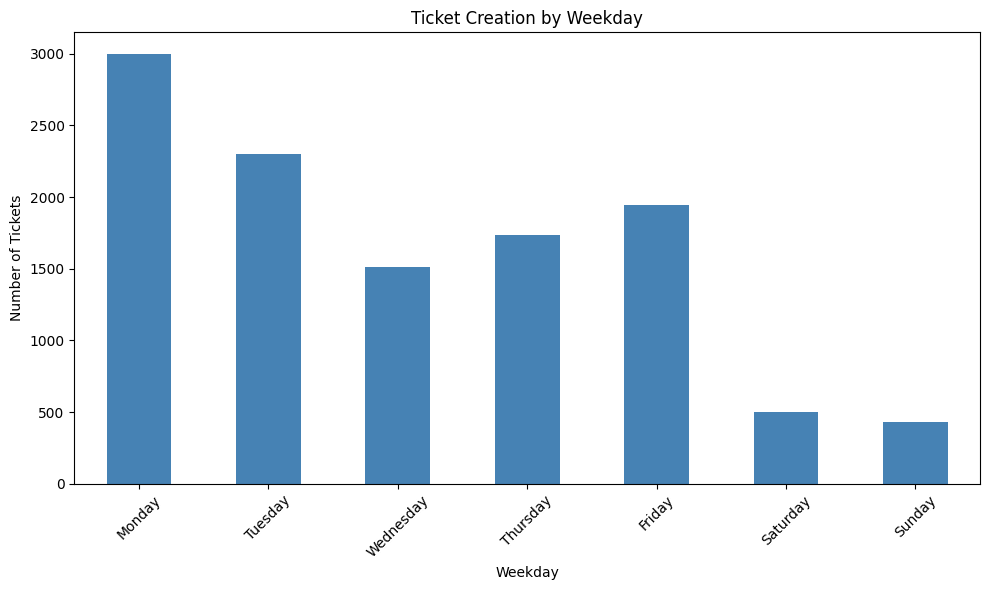

In [8]:
# Convert 'opened' column to datetime and extract weekday
df['opened'] = pd.to_datetime(df['opened'])
df['weekday'] = df['opened'].dt.day_name()

# Count tickets by weekday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df['weekday'].value_counts().reindex(weekday_order)

# Plot tickets by weekday
plt.figure(figsize=(10, 6))
weekday_counts.plot(kind='bar', color='steelblue')
plt.title('Ticket Creation by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Assignment group clustering

- Assignment group names were mapped to broader functional clusters using keyword-based rules.
- Each group name was lowercased and matched against predefined patterns.
- Matching groups were assigned to a single high-level cluster; unmatched groups were labeled “Other”.
- A new column (assignment_cluster) was created from this mapping.
- A stacked bar chart was created to visualize ticket counts by weekday and assignment cluster.

Result: This reduced category complexity and improved interpretability for analysis and visualization.

<Figure size 1200x800 with 0 Axes>

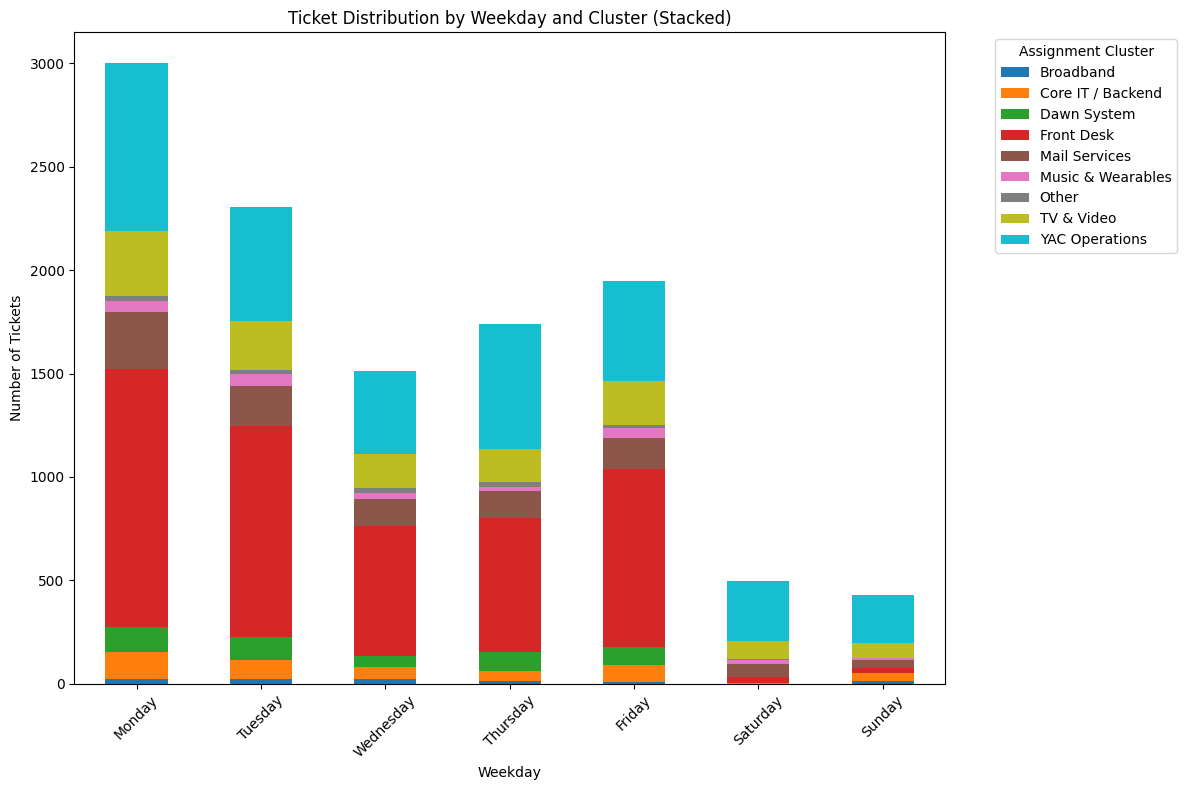

In [9]:
# 1. DEFINE CLUSTERS (The mapping logic)
def map_cluster(group_name):
    group_name = str(group_name).lower()
    if 'yac' in group_name: return 'YAC Operations'
    if 'front desk' in group_name or 'front np' in group_name: return 'Front Desk'
    if 'tv-' in group_name or 'vod' in group_name or 'video' in group_name: return 'TV & Video'
    if 'mail' in group_name: return 'Mail Services'
    if 'cg_' in group_name or 'coreit' in group_name: return 'Core IT / Backend'
    if 'dawn' in group_name: return 'Dawn System'
    if 'music' in group_name or 'smartwatch' in group_name: return 'Music & Wearables'
    if 'broad' in group_name or 'internet' in group_name: return 'Broadband'
    return 'Other'

# 2. APPLY MAPPING
df['assignment_cluster'] = df['assignment_group'].apply(map_cluster)

# 3. CREATE CROSSTAB (Weekday vs. Cluster)
ct = pd.crosstab(df['weekday'], df['assignment_cluster'])
ct = ct.reindex(weekday_order)

# 4. PLOT STACKED BAR CHART
plt.figure(figsize=(12, 8))
ct.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab10')
plt.title('Ticket Distribution by Weekday and Cluster (Stacked)')
plt.xlabel('Weekday')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.legend(title='Assignment Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Ticket Distribution by Ticket and CLuster:
- Ticket volume is highest on weekdays and drops sharply on weekends.
- Monday and Tuesday show the highest overall ticket counts.
- YAC Operations and Front Desk dominate ticket volume across all weekdays.
- Other clusters contribute consistently but at much lower volumes.
- Cluster proportions remain stable over the week, indicating consistent ticket routing behavior

### Urgency / Prio

- Urgency labels were mapped from long textual descriptions to simplified categories (Low, Medium, High).
- A new column (urgency_simplified) was created using this mapping.
- Bar charts were created to visualize the distribution of tickets by urgency and by priority.
- Ticket counts for urgency and priority levels were printed for reference.

Result: The dataset is heavily skewed toward low urgency and low priority tickets, with very few medium and high urgency/priority cases.

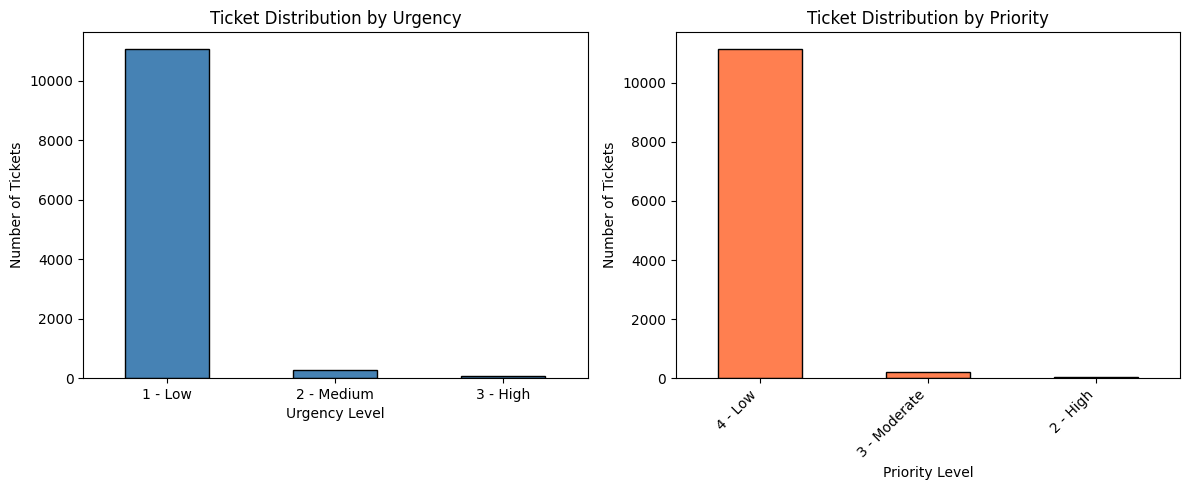

Urgency Distribution:
urgency_simplified
1 - Low       11082
2 - Medium      274
3 - High         66
Name: count, dtype: int64

Priority Distribution:
priority
4 - Low         11150
3 - Moderate      224
2 - High           56
Name: count, dtype: int64


In [10]:
# Define urgency mapping for consistent labeling
urgency_mapping = {
    'High - Significant degradation or partial loss of a business-critical service or application': '3 - High',
    'Medium - Degradation of a business-critical IT application': '2 - Medium',
    'Low - Total loss or degradation of a non-business-critical IT application': '1 - Low'
}

# Apply mapping to create simplified urgency column
df['urgency_simplified'] = df['urgency'].map(urgency_mapping)

# Visualize urgency distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['urgency_simplified'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Ticket Distribution by Urgency')
plt.xlabel('Urgency Level')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)
plt.tight_layout()

plt.subplot(1, 2, 2)
df['priority'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Ticket Distribution by Priority')
plt.xlabel('Priority Level')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

# Show counts
print("Urgency Distribution:")
print(df['urgency_simplified'].value_counts().sort_index())
print("\nPriority Distribution:")
print(df['priority'].value_counts())

### Word Analysis

#### Length Distributions

- Text length in characters was computed for both ticket titles and descriptions.
- Histograms were created to visualize the length distributions of titles and descriptions.

Result: Titles are generally short and consistent, while descriptions vary widely and include long right-tailed outliers.

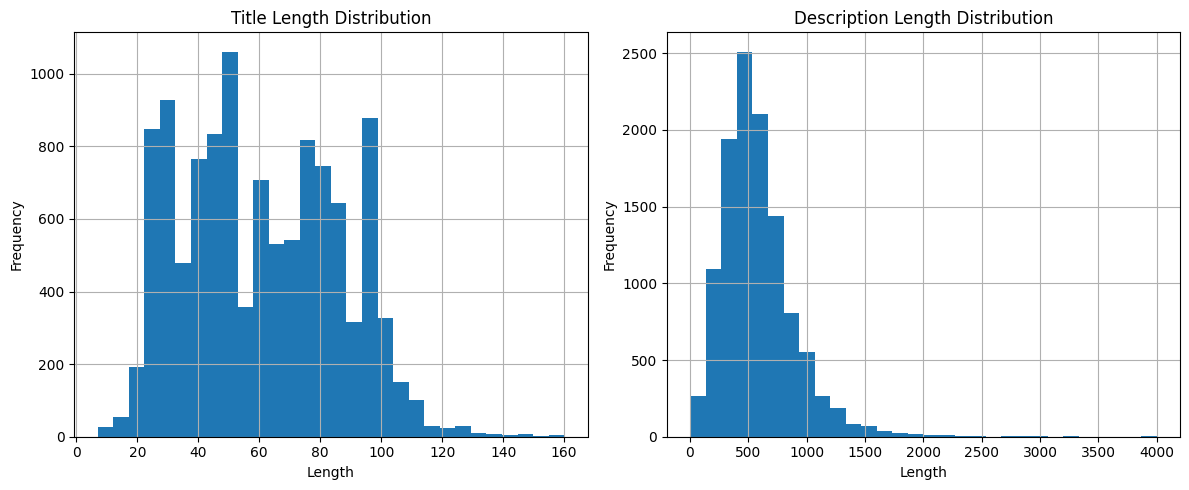

In [11]:
# Calculate text length for title and description
df['title_length'] = df['title'].astype(str).apply(len)
df['description_length'] = df['description'].astype(str).apply(len)

# Visualize text length distributions
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
df['title_length'].hist(bins=30)
plt.title('Title Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
df['description_length'].hist(bins=30)
plt.title('Description Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Word Frequency
- Titles and descriptions were tokenized into words and converted to lowercase.
- English stopwords were removed to focus on informative terms.
- The most frequent words in titles and descriptions were counted and visualized using bar charts.

Result: Ticket text is dominated by recurring domain-specific terms (e.g. customer, order, error, support), indicating strong vocabulary repetition.

In [12]:
# NER tagging for company-specific names using spaCy
import spacy
nlp = spacy.load('en_core_web_sm')

# Add stopwords and matplotlib imports
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))



[nltk_data] Downloading package stopwords to
[nltk_data]     /home/azureuser/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
# Most common words in title and description, removing stopwords
from collections import Counter
import re

def get_words(text_series):
    words = []
    for text in text_series.dropna():
        words += re.findall(r'\w+', text.lower())
    return words

def remove_stopwords(words):
    return [w for w in words if w not in stop_words]

title_words = get_words(df['title'])
description_words = get_words(df['description'])

title_words_nostop = remove_stopwords(title_words)
description_words_nostop = remove_stopwords(description_words)

title_counter = Counter(title_words_nostop)
description_counter = Counter(description_words_nostop)

print('Top 20 words in title (no stopwords):')
print(title_counter.most_common(20))
print('\nTop 20 words in description (no stopwords):')
print(description_counter.most_common(20))

Top 20 words in title (no stopwords):
[('support', 9305), ('dawn', 3175), ('yousee', 3005), ('customer', 2952), ('issues', 2262), ('quote', 1940), ('context', 1744), ('order', 1660), ('tv', 1595), ('mail', 1231), ('cannot', 1165), ('issue', 1084), ('login', 986), ('orders', 953), ('quotes', 894), ('user', 872), ('quotation', 853), ('completed', 797), ('webmail', 775), ('submission', 761)]

Top 20 words in description (no stopwords):
[('customer', 30493), ('order', 10793), ('error', 9467), ('category', 9221), ('app', 8033), ('yousee', 7397), ('quote', 7388), ('cannot', 6907), ('https', 6612), ('nc', 6579), ('nuuday', 6488), ('customerid', 6445), ('prod', 6362), ('bss', 6362), ('nu', 6357), ('prod01', 6350), ('dawn', 5949), ('errorurl', 5885), ('host', 5822), ('wp', 5798)]


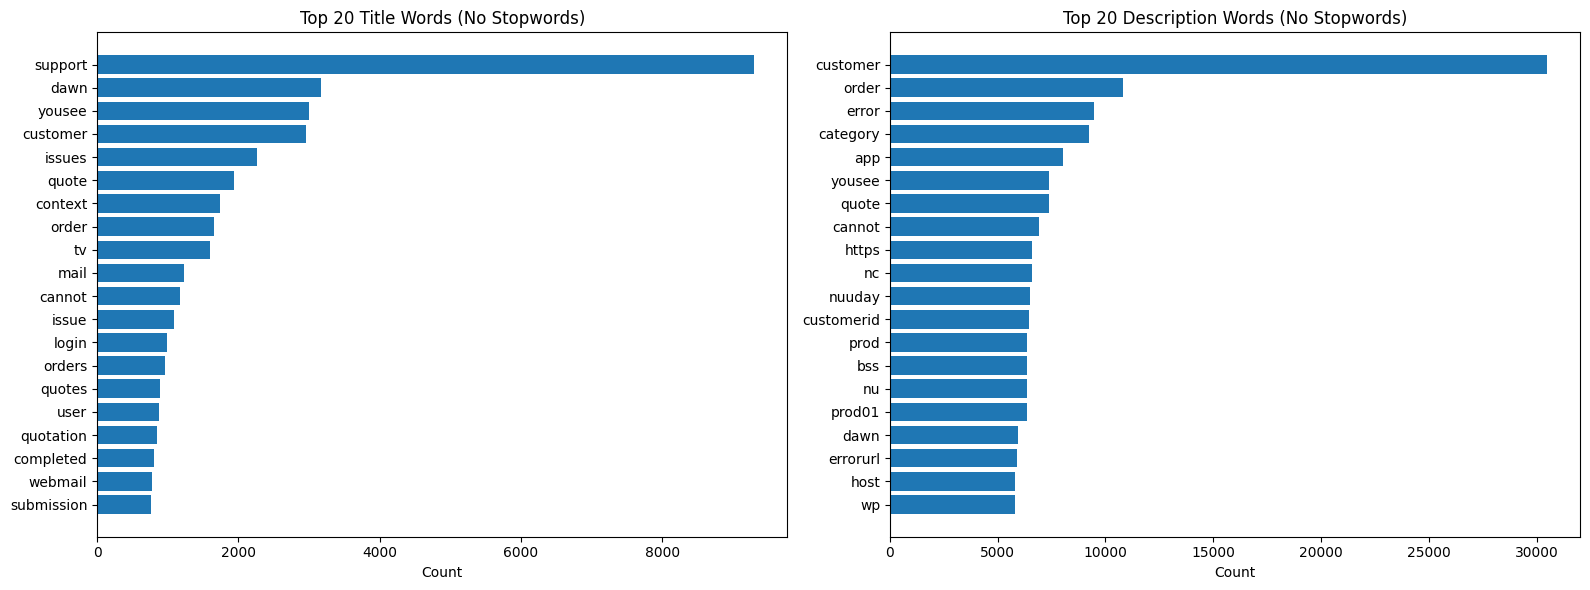

In [14]:
# Visualize top 20 words in title and description (no stopwords)
fig, axes = plt.subplots(1, 2, figsize=(16,6))
title_common = title_counter.most_common(20)
desc_common = description_counter.most_common(20)

axes[0].barh([w for w, _ in reversed(title_common)], [c for _, c in reversed(title_common)])
axes[0].set_title('Top 20 Title Words (No Stopwords)')
axes[0].set_xlabel('Count')

axes[1].barh([w for w, _ in reversed(desc_common)], [c for _, c in reversed(desc_common)])
axes[1].set_title('Top 20 Description Words (No Stopwords)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

### N-Gram Analysis

- Bigrams and trigrams were extracted from title and description text after stopword removal.
- Frequencies of the most common n-grams were computed separately for titles and descriptions.
- Horizontal bar charts were created to visualize the top 20 bigrams and trigrams.

Result: Titles are dominated by short, repetitive operational phrases, while descriptions contain more detailed, system- and process-specific phrases.

In [15]:
# Extract bigrams and trigrams from text
from collections import Counter
import re

def get_ngrams(words, n=2):
    ngrams = []
    for i in range(len(words) - n + 1):
        ngram = ' '.join(words[i:i+n])
        ngrams.append(ngram)
    return ngrams

# Get bigrams and trigrams
title_bigrams = get_ngrams(title_words_nostop, n=2)
title_trigrams = get_ngrams(title_words_nostop, n=3)
description_bigrams = get_ngrams(description_words_nostop, n=2)
description_trigrams = get_ngrams(description_words_nostop, n=3)

# Count occurrences
title_bigram_counter = Counter(title_bigrams)
title_trigram_counter = Counter(title_trigrams)
description_bigram_counter = Counter(description_bigrams)
description_trigram_counter = Counter(description_trigrams)

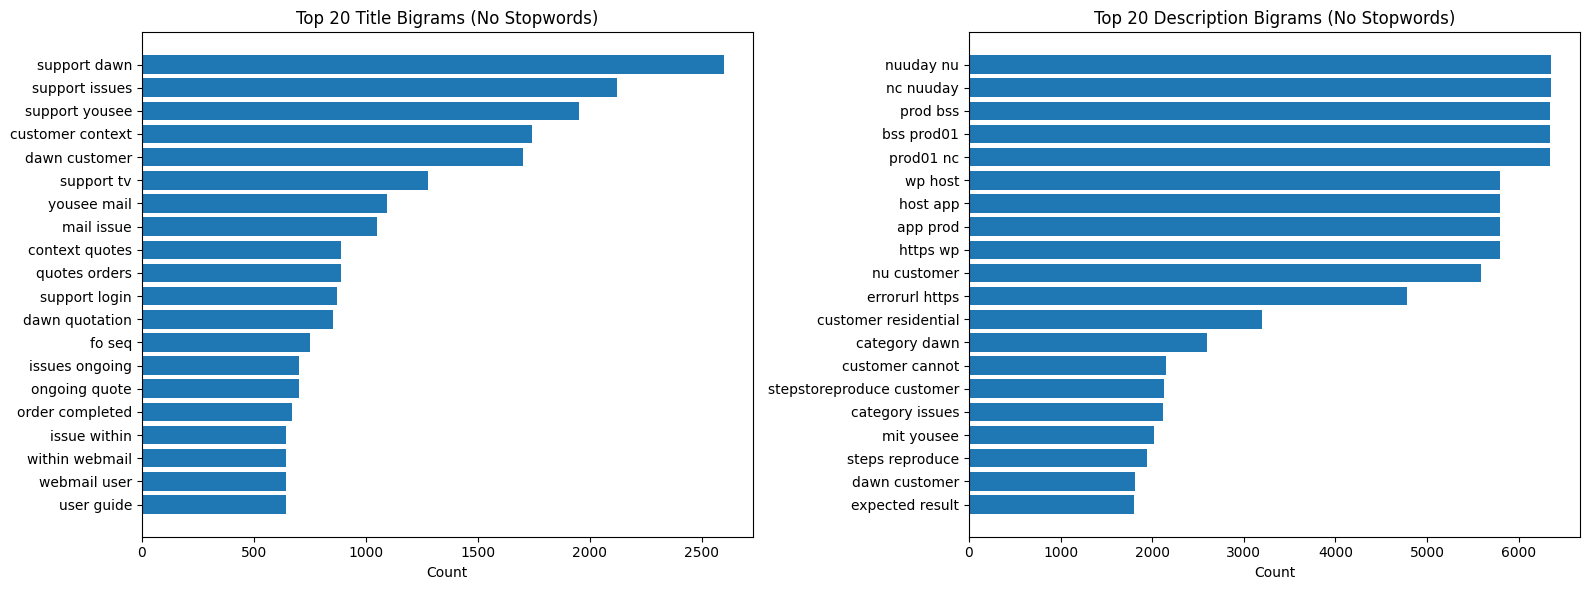

In [16]:
# Visualize top 20 bigrams for title and description
fig, axes = plt.subplots(1, 2, figsize=(16,6))
title_bigram_common = title_bigram_counter.most_common(20)
desc_bigram_common = description_bigram_counter.most_common(20)

axes[0].barh([w for w, _ in reversed(title_bigram_common)], [c for _, c in reversed(title_bigram_common)])
axes[0].set_title('Top 20 Title Bigrams (No Stopwords)')
axes[0].set_xlabel('Count')

axes[1].barh([w for w, _ in reversed(desc_bigram_common)], [c for _, c in reversed(desc_bigram_common)])
axes[1].set_title('Top 20 Description Bigrams (No Stopwords)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

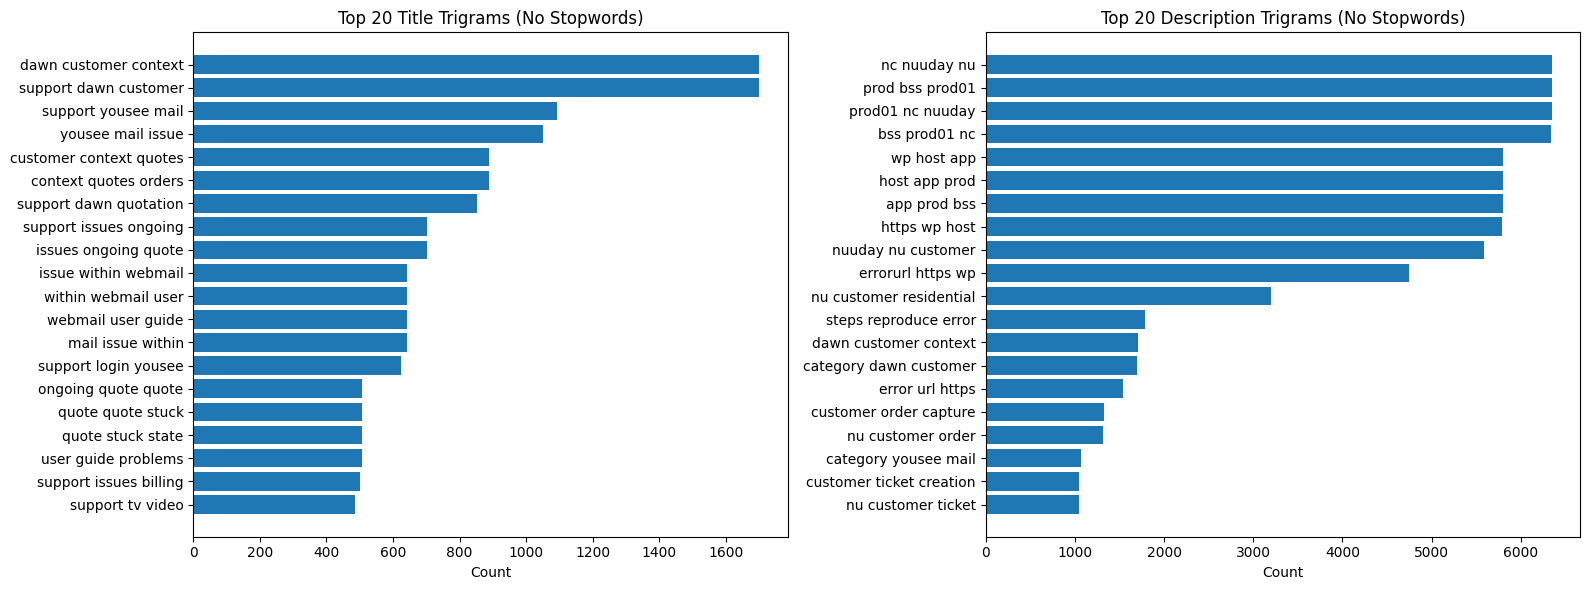

In [17]:
# Visualize top 20 trigrams for title and description
fig, axes = plt.subplots(1, 2, figsize=(16,6))
title_trigram_common = title_trigram_counter.most_common(20)
desc_trigram_common = description_trigram_counter.most_common(20)

axes[0].barh([w for w, _ in reversed(title_trigram_common)], [c for _, c in reversed(title_trigram_common)])
axes[0].set_title('Top 20 Title Trigrams (No Stopwords)')
axes[0].set_xlabel('Count')

axes[1].barh([w for w, _ in reversed(desc_trigram_common)], [c for _, c in reversed(desc_trigram_common)])
axes[1].set_title('Top 20 Description Trigrams (No Stopwords)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

### NER Analysis
- Named Entity Recognition (NER) was applied to ticket titles and descriptions using a pre-trained spaCy model.
- Extracted entities were lowercased and pure numeric entities were removed.
- Entity frequencies were computed separately for titles and descriptions.
- Bar charts were created to visualize the top 20 named entities in titles and descriptions.

Result: Frequently occurring entities include system names, technical terms, and identifiers, indicating recurring systems and components referenced in tickets.

In [18]:
def extract_entities(text_series):
    entities = []
    for doc in nlp.pipe(text_series, batch_size=1000):
        entities.extend([
            ent.text.lower()
            for ent in doc.ents
            if not re.fullmatch(r"\d+", ent.text)  # Exclude pure numbers
        ])
    return entities

# Extract entities
title_entities = extract_entities(title_words_nostop)
description_entities = extract_entities(description_words_nostop)

# Count occurrences
title_entity_counter = Counter(title_entities)
description_entity_counter = Counter(description_entities)

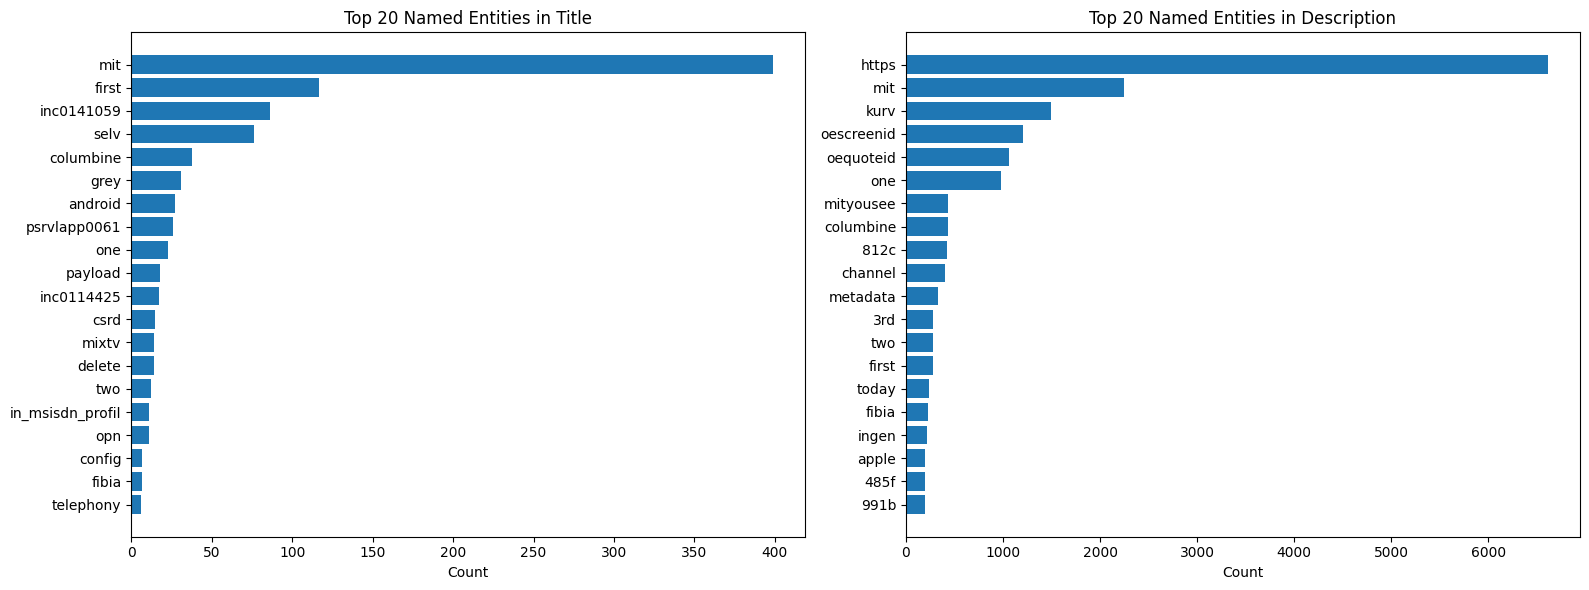

In [19]:
# Visualize top 20 entities for title and description
fig, axes = plt.subplots(1, 2, figsize=(16,6))
title_entity_common = title_entity_counter.most_common(20)
desc_entity_common = description_entity_counter.most_common(20)

axes[0].barh([w for w, _ in reversed(title_entity_common)], [c for _, c in reversed(title_entity_common)])
axes[0].set_title('Top 20 Named Entities in Title')
axes[0].set_xlabel('Count')

axes[1].barh([w for w, _ in reversed(desc_entity_common)], [c for _, c in reversed(desc_entity_common)])
axes[1].set_title('Top 20 Named Entities in Description')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Sentiment

- Sentiment polarity was computed for each ticket description using TextBlob.
- Empty or missing descriptions were assigned a neutral sentiment score (0.0).
- Descriptive statistics and a histogram were created to analyze the overall sentiment distribution.
- Average sentiment was calculated and visualized by urgency level.

Result: Overall sentiment is centered around neutral, with higher urgency tickets showing increasingly negative sentiment compared to low-urgency tickets.

In [20]:
# Install and import TextBlob for sentiment analysis
from textblob import TextBlob

# Calculate sentiment polarity for description text
def get_sentiment(text):
    if pd.isna(text) or text == '':
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

df['description_sentiment'] = df['description'].apply(get_sentiment)

print("Sentiment statistics:")
print(df['description_sentiment'].describe())

Sentiment statistics:
count    11430.000000
mean         0.000923
std          0.154562
min         -0.800000
25%         -0.080000
50%          0.000000
75%          0.066667
max          0.900000
Name: description_sentiment, dtype: float64


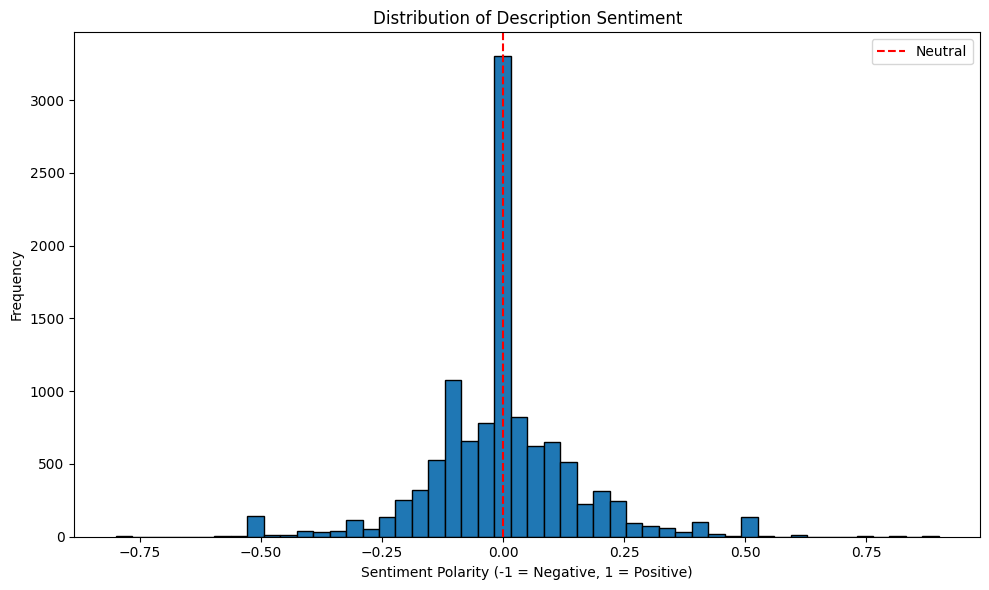

In [21]:
# Visualize sentiment distribution
plt.figure(figsize=(10, 6))
plt.hist(df['description_sentiment'], bins=50, edgecolor='black')
plt.title('Distribution of Description Sentiment')
plt.xlabel('Sentiment Polarity (-1 = Negative, 1 = Positive)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral')
plt.legend()
plt.tight_layout()
plt.show()

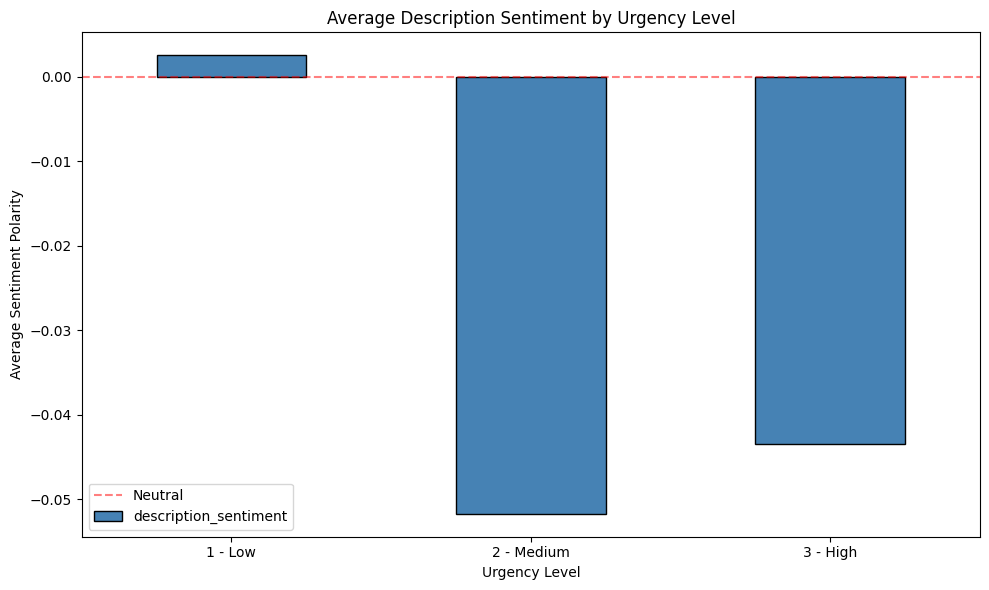


Average Sentiment by Urgency Level:
urgency_simplified
1 - Low       0.002565
2 - Medium   -0.051706
3 - High     -0.043446
Name: description_sentiment, dtype: float64


In [22]:
# Create a bar plot showing average sentiment per urgency level
urgency_sentiment_avg = df.groupby('urgency_simplified')['description_sentiment'].mean().sort_index()

plt.figure(figsize=(10, 6))
urgency_sentiment_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Description Sentiment by Urgency Level')
plt.xlabel('Urgency Level')
plt.ylabel('Average Sentiment Polarity')
plt.xticks(rotation=0)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Neutral')
plt.legend()
plt.tight_layout()
plt.show()

# Show statistics
print("\nAverage Sentiment by Urgency Level:")
print(urgency_sentiment_avg)

### Bivariate Analysis

#### Urgency vs. Text Content
- Compared the most frequent words in ticket descriptions across urgency levels (Low, Medium, High).

Result:

- Low-urgency tickets focus on customer, order, and category-related terms.
- Medium-urgency tickets increasingly contain process- and error-related language (e.g. error, reproduce, steps).
- High-urgency tickets emphasize failure, access, and blocking issues, indicating more critical system problems.

In [23]:
# 1. Urgency vs. Text - Most common words per urgency level
print("=" * 60)
print("1. URGENCY vs. TEXT ANALYSIS")
print("=" * 60)

for urgency_level in sorted(df['urgency_simplified'].dropna().unique()):
    subset_indices = df[df['urgency_simplified'] == urgency_level].index
    # Filter words that belong to this urgency level
    words_for_urgency = []
    for idx in subset_indices:
        if idx < len(df) and pd.notna(df.loc[idx, 'description']):
            text_words = re.findall(r'\w+', str(df.loc[idx, 'description']).lower())
            words_for_urgency.extend([w for w in text_words if w not in stop_words and len(w) > 2])
    
    counter = Counter(words_for_urgency)
    print(f"\n{urgency_level}:")
    print(f"Top 10 words: {counter.most_common(10)}")

1. URGENCY vs. TEXT ANALYSIS

1 - Low:
Top 10 words: [('customer', 30121), ('order', 10499), ('category', 9214), ('error', 8818), ('app', 7818), ('yousee', 7323), ('quote', 7000), ('cannot', 6870), ('https', 6368), ('customerid', 6304)]

2 - Medium:
Top 10 words: [('error', 561), ('quote', 361), ('customer', 316), ('order', 271), ('expected', 244), ('summary', 243), ('result', 234), ('steps', 234), ('reproduce', 232), ('https', 211)]

3 - High:
Top 10 words: [('error', 75), ('customer', 49), ('host', 45), ('memory', 42), ('psrvlapp0061', 39), ('bss', 34), ('expected', 33), ('https', 31), ('message', 31), ('app', 30)]


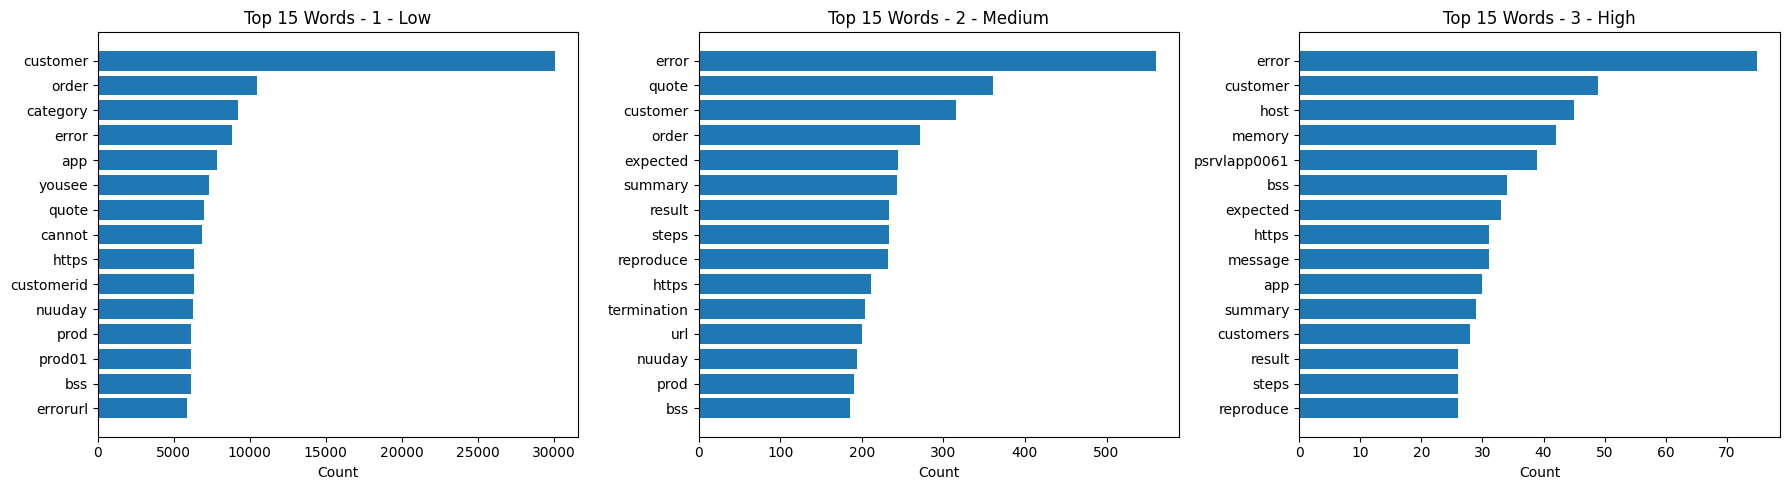

In [24]:
# Visualize top words by urgency level
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
urgency_levels = sorted(df['urgency_simplified'].dropna().unique())

for idx, urgency_level in enumerate(urgency_levels):
    subset_indices = df[df['urgency_simplified'] == urgency_level].index
    words_for_urgency = []
    for row_idx in subset_indices:
        if row_idx < len(df) and pd.notna(df.loc[row_idx, 'description']):
            text_words = re.findall(r'\w+', str(df.loc[row_idx, 'description']).lower())
            words_for_urgency.extend([w for w in text_words if w not in stop_words and len(w) > 2])
    
    counter = Counter(words_for_urgency)
    top_words = counter.most_common(15)
    
    axes[idx].barh([w for w, _ in reversed(top_words)], [c for _, c in reversed(top_words)])
    axes[idx].set_title(f'Top 15 Words - {urgency_level}')
    axes[idx].set_xlabel('Count')

plt.tight_layout()
plt.show()

#### Assignment Cluster vs. Description Characteristics

- Analyzed average description length, title length, sentiment, and ticket volume per assignment cluster.

Result:

- Front Desk, Dawn System, and YAC Operations receive the longest and most detailed descriptions.
- Broadband and TV & Video tickets tend to be shorter but more negatively worded.
- Sentiment varies systematically by cluster, reflecting different problem types and user frustration levels.

In [25]:
# 2. Assignment Cluster vs. Description - Text characteristics by cluster
print("\n" + "=" * 60)
print("2. ASSIGNMENT CLUSTER vs. DESCRIPTION ANALYSIS")
print("=" * 60)

cluster_stats = df.groupby('assignment_cluster').agg({
    'description_length': ['mean', 'median', 'std'],
    'title_length': ['mean', 'median'],
    'description_sentiment': 'mean',
    'number': 'count'
}).round(2)

cluster_stats.columns = ['_'.join(col).strip() for col in cluster_stats.columns]
cluster_stats = cluster_stats.sort_values('number_count', ascending=False)
print("\nDescription characteristics by Assignment Cluster:")
print(cluster_stats)


2. ASSIGNMENT CLUSTER vs. DESCRIPTION ANALYSIS

Description characteristics by Assignment Cluster:
                    description_length_mean  description_length_median  \
assignment_cluster                                                       
Front Desk                           686.44                      635.5   
YAC Operations                       593.24                      550.0   
TV & Video                           412.54                      384.0   
Mail Services                        352.86                      317.5   
Dawn System                          719.13                      616.0   
Core IT / Backend                    372.48                      311.5   
Music & Wearables                    497.55                      456.5   
Broadband                            439.18                      375.0   
Other                                580.45                      447.0   

                    description_length_std  title_length_mean  \
assignment_cluster  

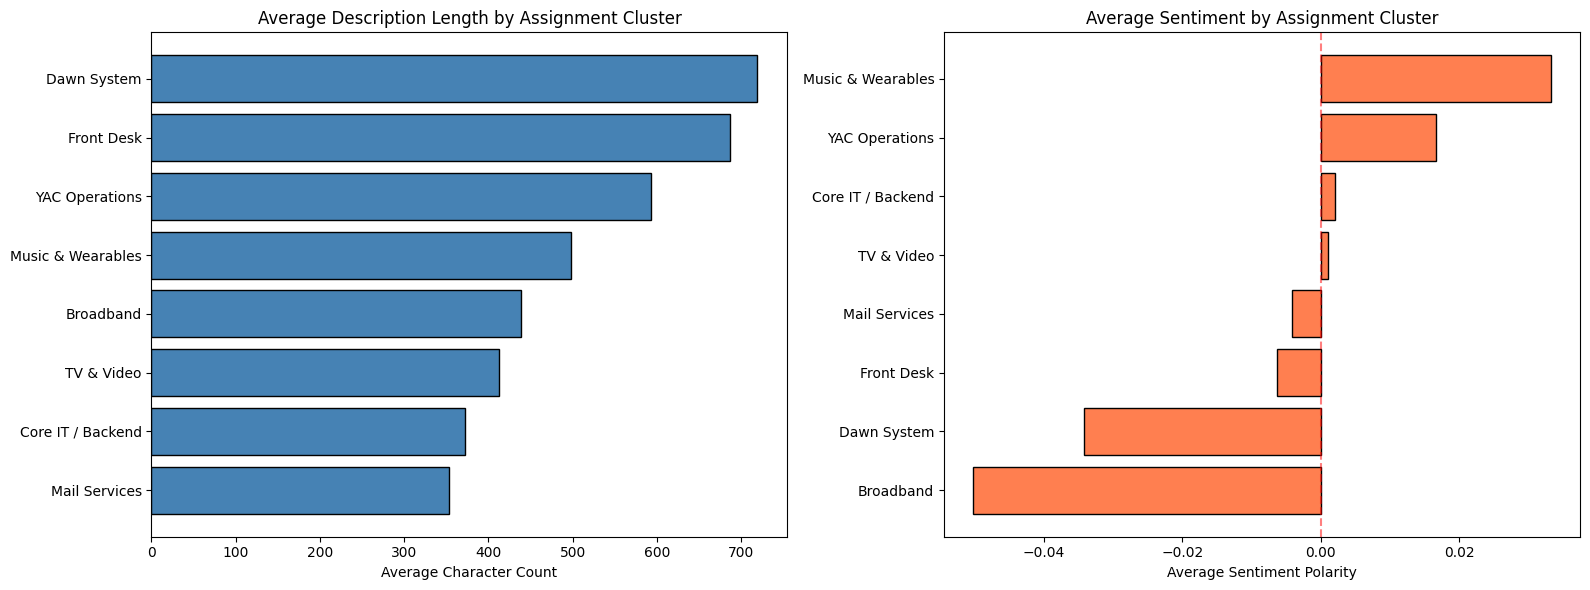

In [26]:
# Visualize text length by assignment cluster
top_clusters = df['assignment_cluster'].value_counts().head(8).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Description length by cluster
cluster_desc_length = df[df['assignment_cluster'].isin(top_clusters)].groupby('assignment_cluster')['description_length'].mean().sort_values()
axes[0].barh(cluster_desc_length.index, cluster_desc_length.values, color='steelblue', edgecolor='black')
axes[0].set_title('Average Description Length by Assignment Cluster')
axes[0].set_xlabel('Average Character Count')

# Sentiment by cluster
cluster_sentiment = df[df['assignment_cluster'].isin(top_clusters)].groupby('assignment_cluster')['description_sentiment'].mean().sort_values()
axes[1].barh(cluster_sentiment.index, cluster_sentiment.values, color='coral', edgecolor='black')
axes[1].set_title('Average Sentiment by Assignment Cluster')
axes[1].set_xlabel('Average Sentiment Polarity')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Assignment Group vs. Text and Urgency

- Compared top assignment groups by description length, sentiment, dominant urgency, and ticket volume.

Result:

- High-volume groups (e.g. Front Desk, YAC-Resolution) consistently receive long descriptions.
- Nearly all top groups are dominated by low-urgency tickets, suggesting operational rather than critical issues.
- Differences in description length reflect group-specific workflows and reporting practices.

In [27]:
# 3. Assignment Group Analysis - Detailed group comparison
print("\n" + "=" * 60)
print("3. ASSIGNMENT GROUP ANALYSIS")
print("=" * 60)

# Get top 10 assignment groups
top_groups = df['assignment_group'].value_counts().head(10).index
group_analysis = df[df['assignment_group'].isin(top_groups)].groupby('assignment_group').agg({
    'description_length': ['mean', 'std'],
    'title_length': 'mean',
    'description_sentiment': 'mean',
    'urgency_simplified': lambda x: x.mode()[0] if len(x.mode()) > 0 else None,
    'number': 'count'
}).round(2)

group_analysis.columns = ['_'.join(col).strip() if col[1] else col[0] for col in group_analysis.columns]
group_analysis = group_analysis.sort_values('description_length_mean', ascending=False)
print("\nTop 10 Assignment Groups by ticket count:")
print(group_analysis)


3. ASSIGNMENT GROUP ANALYSIS

Top 10 Assignment Groups by ticket count:
                                       description_length_mean  \
assignment_group                                                 
Dawn fallouts                                           717.70   
Nuuday Front Desk                                       696.55   
YAC-Req.Info                                            648.98   
YAC-Resolution                                          594.56   
CG_EU_DCT_CIAM                                          514.46   
YAC-Validation                                          493.36   
TV-Video On Demand (VOD) – Validation                   455.86   
YouSee Mail Validation                                  352.61   
TV-Misc – Validation                                    331.00   
CG_MIX_COREIT_NUU-ICH                                   181.59   

                                       description_length_std  \
assignment_group                                                
Dawn

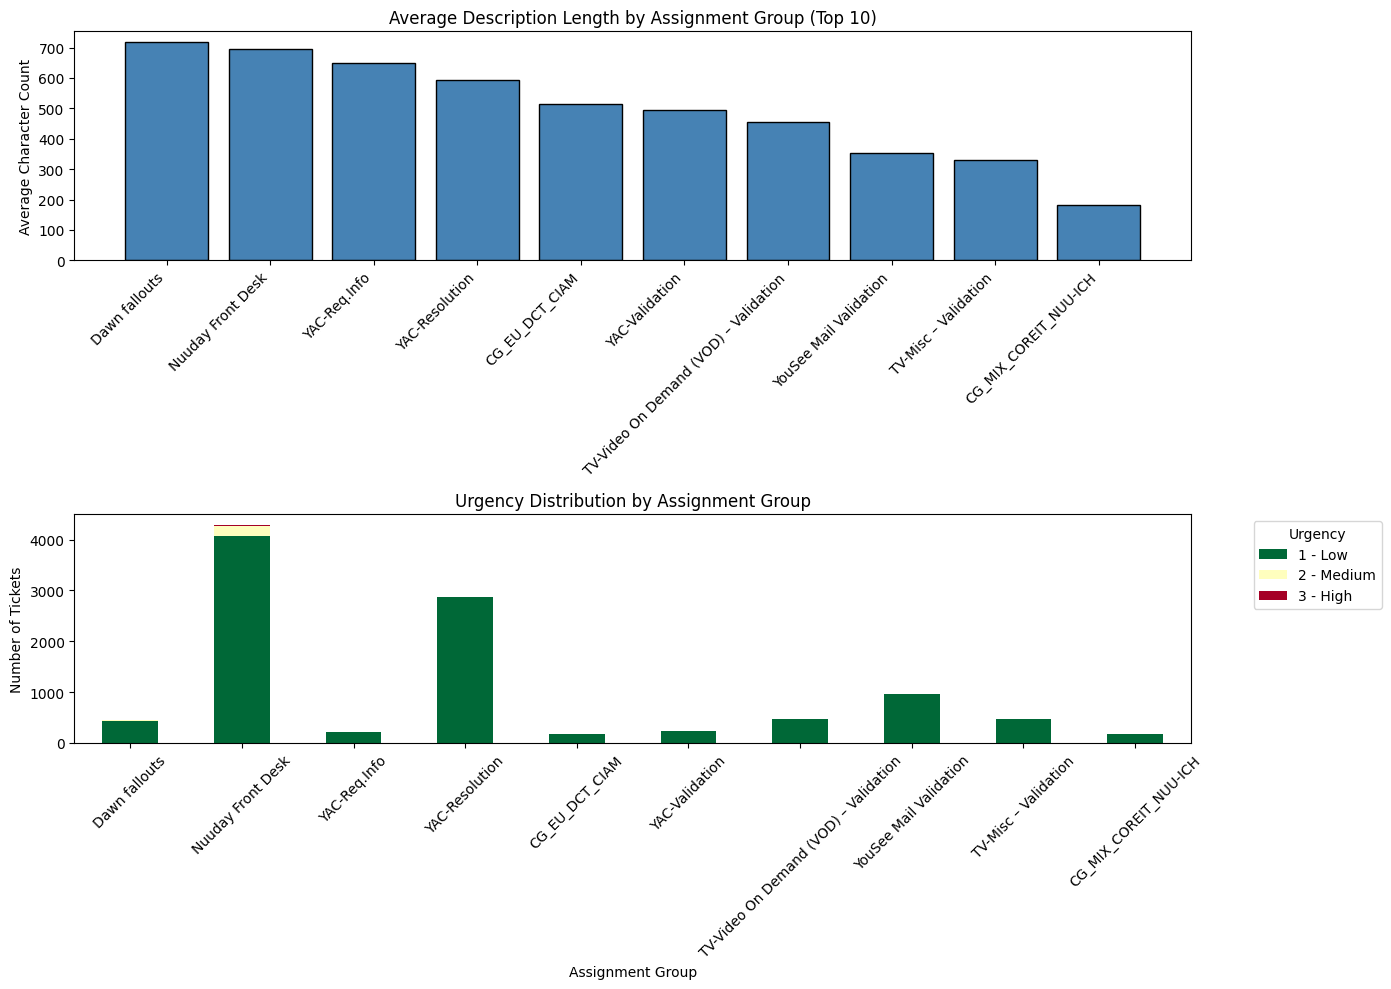

In [28]:
# Visualize assignment group comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Description length comparison
group_lengths = df[df['assignment_group'].isin(top_groups)].groupby('assignment_group')['description_length'].mean().sort_values(ascending=False)
axes[0].bar(range(len(group_lengths)), group_lengths.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(group_lengths)))
axes[0].set_xticklabels(group_lengths.index, rotation=45, ha='right')
axes[0].set_title('Average Description Length by Assignment Group (Top 10)')
axes[0].set_ylabel('Average Character Count')

# Ticket volume and urgency distribution
urgency_by_group = pd.crosstab(df[df['assignment_group'].isin(top_groups)]['assignment_group'], 
                                df[df['assignment_group'].isin(top_groups)]['urgency_simplified'])
urgency_by_group = urgency_by_group.loc[group_lengths.index]
urgency_by_group.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn_r')
axes[1].set_title('Urgency Distribution by Assignment Group')
axes[1].set_ylabel('Number of Tickets')
axes[1].set_xlabel('Assignment Group')
axes[1].legend(title='Urgency', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Priority vs. Sentiment

Examined sentiment distributions and average sentiment across priority levels.

Result:

- High-priority tickets show significantly more negative sentiment.
- Moderate-priority tickets cluster closer to neutral sentiment.
- Low-priority tickets are mostly neutral or slightly positive, indicating lower perceived impact.


4. PRIORITY vs. SENTIMENT ANALYSIS

Sentiment statistics by Priority:
              description_sentiment_mean  description_sentiment_median  \
priority                                                                 
2 - High                          -0.059                         0.000   
3 - Moderate                      -0.057                        -0.065   
4 - Low                            0.002                         0.000   

              description_sentiment_std  number_count  
priority                                               
2 - High                          0.133            56  
3 - Moderate                      0.145           224  
4 - Low                           0.155         11150  


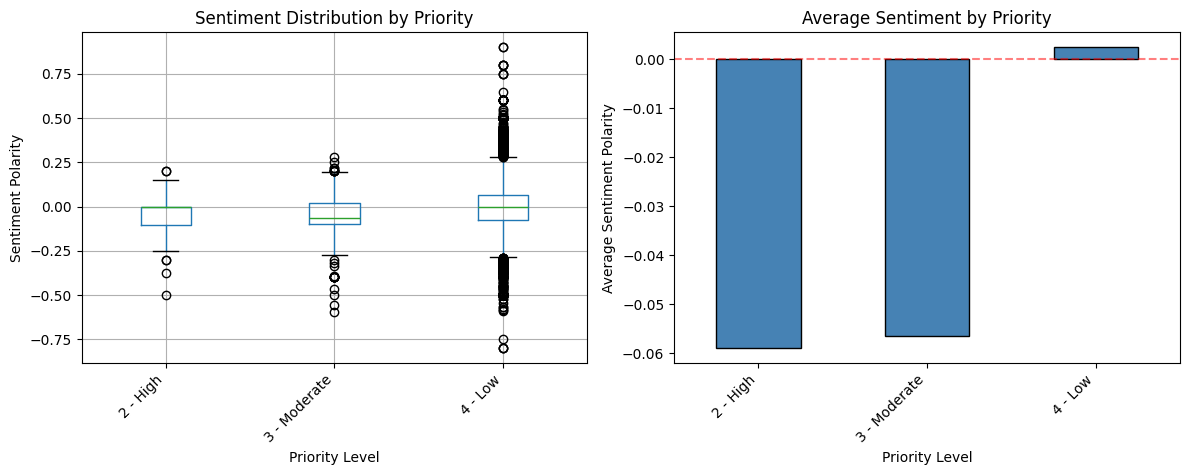

In [29]:
# 4. Priority vs. Sentiment Analysis
print("\n" + "=" * 60)
print("4. PRIORITY vs. SENTIMENT ANALYSIS")
print("=" * 60)

priority_sentiment = df.groupby('priority').agg({
    'description_sentiment': ['mean', 'median', 'std'],
    'number': 'count'
}).round(3)

priority_sentiment.columns = ['_'.join(col).strip() for col in priority_sentiment.columns]
print("\nSentiment statistics by Priority:")
print(priority_sentiment)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df.boxplot(column='description_sentiment', by='priority', ax=plt.gca())
plt.title('Sentiment Distribution by Priority')
plt.suptitle('')
plt.xlabel('Priority Level')
plt.ylabel('Sentiment Polarity')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
priority_sent_avg = df.groupby('priority')['description_sentiment'].mean().sort_index()
priority_sent_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Sentiment by Priority')
plt.xlabel('Priority Level')
plt.ylabel('Average Sentiment Polarity')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Assignment Cluster vs. Keywords (Sanity Check)

- Identified dominant keywords within major assignment clusters to detect potential misalignments.

Result:

- Keyword sets largely match cluster semantics (e.g. service- or system-specific terms).
- Minor overlaps across clusters suggest shared systems or occasional misrouting rather than systematic labeling errors.

In [30]:
# 5. Cross-analysis: Cluster keyword analysis
print("\n" + "=" * 60)
print("5. CLUSTER KEYWORD ANALYSIS - Potential Misalignments")
print("=" * 60)

# Check if certain keywords appear more in unexpected clusters
for cluster in df['assignment_cluster'].value_counts().head(5).index:
    subset_indices = df[df['assignment_cluster'] == cluster].index
    words_for_cluster = []
    for row_idx in subset_indices:
        if row_idx < len(df) and pd.notna(df.loc[row_idx, 'description']):
            text_words = re.findall(r'\w+', str(df.loc[row_idx, 'description']).lower())
            words_for_cluster.extend([w for w in text_words if w not in stop_words and len(w) > 3])
    
    counter = Counter(words_for_cluster)
    print(f"\n{cluster} - Top 15 keywords:")
    print(counter.most_common(15))


5. CLUSTER KEYWORD ANALYSIS - Potential Misalignments

Front Desk - Top 15 keywords:
[('customer', 12121), ('order', 6632), ('error', 5705), ('quote', 5255), ('https', 3672), ('nuuday', 3662), ('prod', 3586), ('prod01', 3579), ('customerid', 3502), ('host', 3196), ('dawn', 3103), ('category', 3013), ('errorurl', 2722), ('expectedbehaviour', 2147), ('cannot', 2080)]

YAC Operations - Top 15 keywords:
[('customer', 11705), ('category', 3354), ('errorurl', 2754), ('cannot', 2660), ('customerid', 2379), ('yousee', 2378), ('order', 2351), ('expectedbehaviour', 2333), ('dawn', 2085), ('https', 2078), ('nuuday', 2071), ('prod', 2042), ('prod01', 2042), ('host', 2033), ('stepstoreproduce', 1855)]

TV & Video - Top 15 keywords:
[('customer', 2324), ('category', 1178), ('pathfromcip', 1124), ('play', 1054), ('video', 1044), ('yousee', 872), ('issue', 797), ('timecodeerror', 703), ('contenttitle', 702), ('channels', 680), ('content', 665), ('cannot', 593), ('information', 506), ('demand', 485), 

## Anonymization

In [ ]:
from utils.PII_detection import DanishPIIDetector
detector = DanishPIIDetector()

### Check for sensitive information

In [32]:
results_df = detector.scan_dataframe(
    df, 
    text_column='description',  # or 'title'
    id_column='number'
)
stats = detector.get_summary_stats(results_df)

In [35]:
print("\nPII Detection Summary:")
print(stats)


PII Detection Summary:
{'total_findings': 5709, 'unique_tickets_with_pii': 2832, 'findings_by_type': {'DK_PHONE_NUMBER': 2676, 'PHONE_NUMBER': 1222, 'DK_CPR': 934, 'EMAIL_ADDRESS': 842, 'BANK_ACCOUNT': 35}, 'tickets_by_entity_type': {'BANK_ACCOUNT': 21, 'DK_CPR': 758, 'DK_PHONE_NUMBER': 1602, 'EMAIL_ADDRESS': 542, 'PHONE_NUMBER': 995}}


### Mask and Cross-Check

In [33]:
df_masked = detector.mask_pii_in_dataframe(df, columns_to_mask=['description', 'title'])

Masking PII in column: description
Masking PII in column: title


In [36]:
df_masked.to_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/combined_data_masked.csv', index=False)

In [37]:
results_df_masked = detector.scan_dataframe(
    df_masked, 
    text_column='description',  # or 'title'
    id_column='number'
)
stats_masked = detector.get_summary_stats(results_df_masked)

In [38]:
print("\nPII Detection Summary after masking:")
print(stats_masked)


PII Detection Summary after masking:
{'total_findings': 10, 'unique_tickets_with_pii': 8, 'findings_by_type': {'PHONE_NUMBER': 9, 'EMAIL_ADDRESS': 1}, 'tickets_by_entity_type': {'EMAIL_ADDRESS': 1, 'PHONE_NUMBER': 7}}


In [40]:
df_masked = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/combined_data_masked.csv')
df_masked.head()

,number,opened,reported_on_behalf_of,priority,service,title,description,work_notes,category,on_hold_reason,assignment_group,additional_comments,impact,urgency,weekday,assignment_cluster,urgency_simplified,title_length,description_length,description_sentiment
0,INC0133168,2025-11-30 10:03:13,NaN,4 - Low,Broad- YouSeemail - Prod,Support - YouSee mail/Issue with Mit YouSee/Ca...,When the Customer tries to log in to his email...,NaN,Application,NaN,YouSee Mail Validation,NaN,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...,Sunday,Mail Services,1 - Low,86,334,-0.105000
1,INC0133171,2025-11-30 10:20:22,NaN,4 - Low,TV-Video On Demand (VOD) - PROD,Support - TV/Video on demand/Streamer or Audio,Customer experiences that when they get up at ...,NaN,Application,NaN,TV-Video On Demand (VOD) – Validation,NaN,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...,Sunday,TV & Video,1 - Low,46,322,0.000000
2,INC0133177,2025-11-30 10:53:51,NaN,4 - Low,TV -Misc- Prod,Support - TV/Other/Bland Selv,"After the Customer got a new TV, the Customer'...",NaN,Application,NaN,TV-Misc – Validation,NaN,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...,Sunday,TV & Video,1 - Low,29,411,0.068182
3,INC0133167,2025-11-30 09:47:44,Incident Resolution Support,4 - Low,Dawn Agent UI - PROD,Support - Dawn/With Customer context/Other,It is listed as an ongoing change\n\nCategory:...,30-11-2025 11:40:19 - Casper Hjorth (Work note...,Application,NaN,Nuuday Front Desk,30-11-2025 11:40:19 - Casper Hjorth (Additiona...,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...,Sunday,Front Desk,1 - Low,42,309,-0.133333
4,INC0133169,2025-11-30 10:05:27,Incident Resolution Support,4 - Low,Dawn Agent UI - PROD,Support - Dawn/With Customer context/Customer ...,"The Customer has changed address, applied CPR ...",NaN,Application,NaN,YAC-Resolution,30-11-2025 11:47:03 - Casper Hjorth (Additiona...,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...,Sunday,YAC Operations,1 - Low,63,690,0.000000
